In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/skin_dataset'))

['HAM10000_images_part_1', 'HAM10000_images_part_2', 'HAM10000_metadata.csv']


In [ ]:
data_dir = '/content/drive/MyDrive/skin_dataset'

In [ ]:
import pandas as pd

df = pd.read_csv(f"{data_dir}/HAM10000_metadata.csv")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
image_path = {}

for folder in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
    full_path = os.path.join(data_dir, folder)

    for img in os.listdir(full_path):
        image_path[os.path.splitext(img)[0]] = os.path.join(full_path, img)

df['path'] = df['image_id'].map(image_path)

print("Missing paths:", df['path'].isnull().sum())

Missing paths: 0


In [ ]:
label_map = {
    'akiec':0, 'bcc':1, 'bkl':2, 'df':3,
    'mel':4, 'nv':5, 'vasc':6
}

df['label'] = df['dx'].map(label_map)

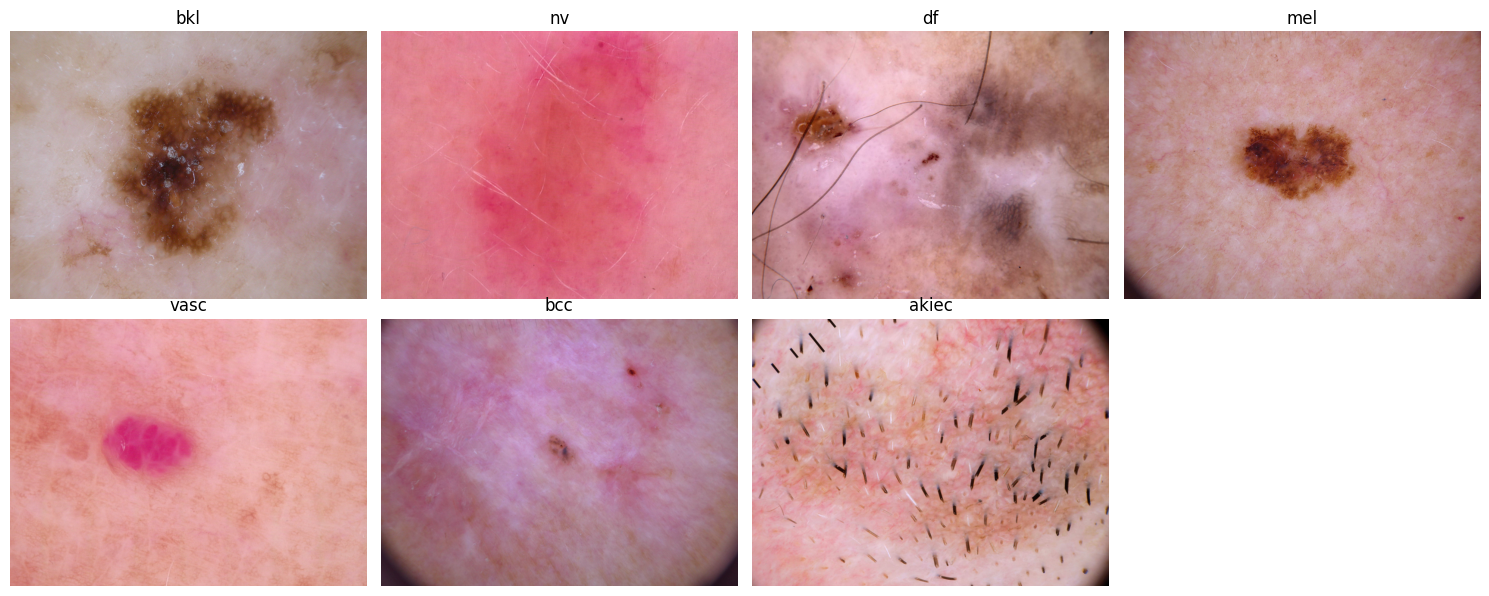

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

classes = df['dx'].unique()

plt.figure(figsize=(15,6))

for i, cls in enumerate(classes):
    sample = df[df['dx'] == cls].sample(1)
    img_path = sample['path'].values[0]

    img = Image.open(img_path)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

In [ ]:
print('Contents of /content/drive/MyDrive:')
print(os.listdir('/content/drive/MyDrive'))

Contents of /content/drive/MyDrive:
['skin_dataset']


In [ ]:
df['dx'].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [ ]:
import os

image_path = {}

for folder in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
    full_path = os.path.join(data_dir, folder)

    for img in os.listdir(full_path):
        image_path[os.path.splitext(img)[0]] = os.path.join(full_path, img)

df['path'] = df['image_id'].map(image_path)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])



In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.df.iloc[idx]['path']).convert('RGB')
        except:
            # skip corrupted image
            return self.__getitem__((idx + 1) % len(self.df))

        label = self.df.iloc[idx]['label']

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
from torch.utils.data import DataLoader

train_dataset = SkinDataset(train_df, train_transform)
val_dataset = SkinDataset(val_df, val_transform)
test_dataset = SkinDataset(test_df, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


In [ ]:
# =========================
# DAY 2: MODEL BUILDING
# =========================

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace FC layer
num_classes = 7

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, num_classes)
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [ ]:
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [ ]:
epochs = 5

print("=== PHASE 1: Train FC ===")

for epoch in range(epochs):
    model.train()
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    acc = correct / len(train_loader.dataset)
    print(f"Epoch {epoch+1}: Train Acc = {acc:.4f}")

=== PHASE 1: Train FC ===
Epoch 1: Train Acc = 0.4859
Epoch 2: Train Acc = 0.5796
Epoch 3: Train Acc = 0.5881
Epoch 4: Train Acc = 0.6055
Epoch 5: Train Acc = 0.6001


In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 8

for epoch in range(epochs):
    model.train()
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    acc = correct / len(train_loader.dataset)
    print(f"Epoch {epoch+1}: Train Acc = {acc:.4f}")

Epoch 1: Train Acc = 0.8390
Epoch 2: Train Acc = 0.8512
Epoch 3: Train Acc = 0.8404
Epoch 4: Train Acc = 0.8623
Epoch 5: Train Acc = 0.8431
Epoch 6: Train Acc = 0.8659
Epoch 7: Train Acc = 0.8606
Epoch 8: Train Acc = 0.8700


In [ ]:
model.eval()

quantized_model = torch.quantization.quantize_dynamic(
    model, {nn.Linear}, dtype=torch.qint8
)

In [ ]:
import torch.nn.utils.prune as prune

model.eval()

# Access the Linear layer inside Sequential
prune.l1_unstructured(model.fc[1], name='weight', amount=0.3)

prune.remove(model.fc[1], 'weight')

Linear(in_features=2048, out_features=7, bias=True)

In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.00001)

In [ ]:
model.eval()
correct = 0

all_preds = []
all_labels = []

# checking model is on correct device after pruning
model.to(device)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)   # normal model (NOT quantized)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = correct / len(test_loader.dataset)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8647029455816275


In [ ]:
torch.save(model.state_dict(), "baseline_86.pth")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.24      0.49      0.32        65
           1       0.51      0.50      0.50       103
           2       0.55      0.34      0.42       220
           3       0.01      0.78      0.03        23
           4       0.48      0.25      0.33       223
           5       0.00      0.00      0.00      1341
           6       0.09      0.86      0.17        28

    accuracy                           0.13      2003
   macro avg       0.27      0.46      0.25      2003
weighted avg       0.15      0.13      0.12      2003



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


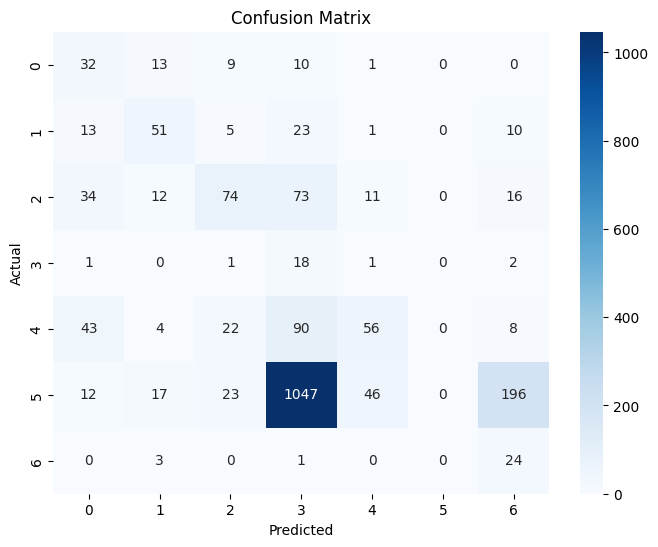

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model.load_state_dict(torch.load('baseline_86.pth'))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving img2.jpg to img2.jpg


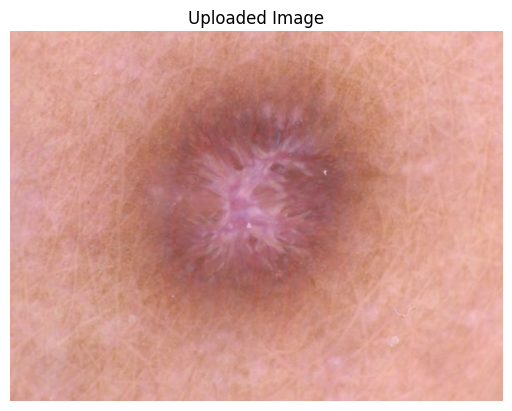

 Prediction: df
 Confidence: 100.00%


In [ ]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

for img_name in uploaded.keys():

    img = Image.open(img_name).convert('RGB')

    # show image
    plt.imshow(img)
    plt.title("Uploaded Image")
    plt.axis('off')
    plt.show()

    # preprocess
    input_img = transform(img).unsqueeze(0).to(device)

    # prediction
    with torch.no_grad():
        outputs = model(input_img)
        probs = torch.softmax(outputs, dim=1)
        _, pred = torch.max(outputs, 1)

    predicted_class = class_names[pred.item()]
    confidence = probs[0][pred].item()

    print(f" Prediction: {predicted_class}")
    print(f" Confidence: {confidence*100:.2f}%")